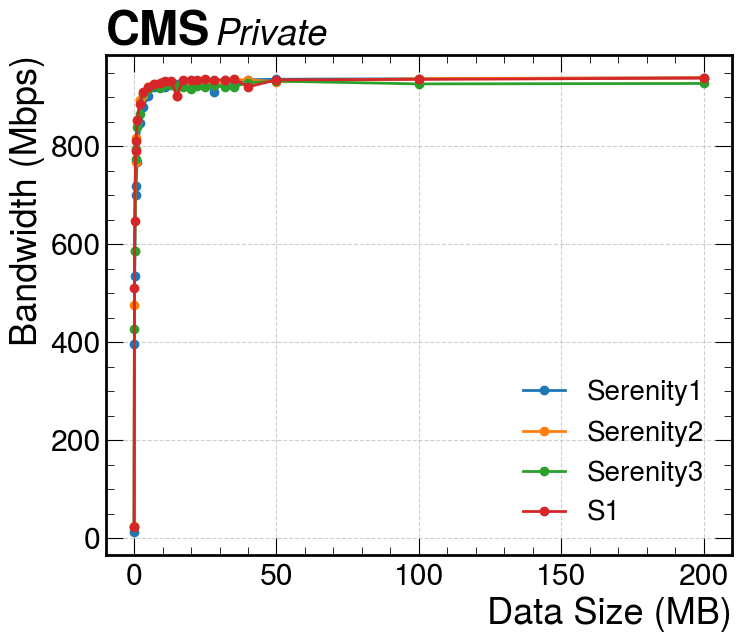

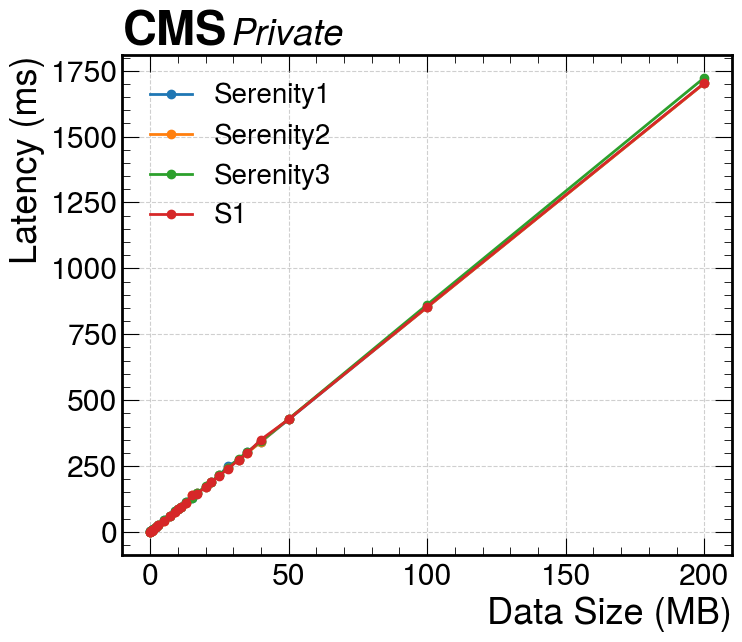

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import sys
import os
import mplhep
import re
plt.style.use(mplhep.style.CMS)

def parse_size(s):
    s = str(s).strip()
    if s == "":
        raise ValueError("Empty size string")

    s_up = s.upper()
    # pure numeric (no letters) -> interpret as bytes
    if re.fullmatch(r"[0-9]+(\.[0-9]+)?", s_up):
        return float(s_up) / 1e6  # bytes -> MB (decimal)

    m = re.match(r"^([0-9]+(?:\.[0-9]+)?)\s*([KMG]?B?|B)$", s_up)
    if not m:
        raise ValueError(f"Unrecognized size format: {s}")

    value = float(m.group(1))
    unit = m.group(2)

    if unit.startswith("G"):
        return value * 1000.0        # GB -> MB (decimal)
    if unit.startswith("M"):
        return value                 # MB
    if unit.startswith("K"):
        return value / 1000.0        # KB -> MB
    # bytes (B) or any other 'B' match
    return value / 1e6               # bytes -> MB


def plot_bandwidth_vs_size(df, outprefix="bandwidth_vs_size", xlim=None, ylim=None):
    plt.figure(figsize=(8, 7))
    plt.plot(
        df['Size_MB'],
        df['Bitrate_Mbps'],
        marker='o',
        linestyle='',
        color='royalblue',
        linewidth=2,
        markersize=6,
        label='Measured Bandwidth'
    )
    plt.title("Bandwidth vs Data Size", fontsize=16)
    plt.xlabel("Data Size (MB)", fontsize=14)
    plt.ylabel("Bandwidth (Mbps)", fontsize=14)
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=10)
    plt.tight_layout()
    mplhep.cms.label("Private", data= True, rlabel="")
    plt.savefig(f"{outprefix}.pdf")
    plt.show()

def plot_latency_vs_size_from_duration(df, outprefix="latency_vs_size_duration", xlim=None, ylim=None):
    # ms
    df['Latency_ms'] = df['Duration'] * 1000

    means = df.groupby('Size_MB')['Latency_ms'].mean().reset_index()

    plt.figure(figsize=(8, 7))
    plt.plot(
        means['Size_MB'],
        means['Latency_ms'],
        marker='o',
        linestyle='-',
        color='green',
        linewidth=2,
        markersize=6,
        label='Measured Latency'
    )
    plt.title("Measured Latency vs Data Size", fontsize=16)
    plt.xlabel("Data Size (MB)", fontsize=14)
    plt.ylabel("Latency (ms)", fontsize=14)
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.legend(fontsize=10)
    mplhep.cms.label("Private", data= True, rlabel="")
    plt.tight_layout()
    plt.savefig(f"{outprefix}.pdf")
    plt.show()


def plot_latency_vs_size(df, outprefix="latency_vs_size", xlim=None, ylim=None):
    # ms
    df['Latency_ms'] = (df['Size_MB'] * 8) / df['Bitrate_Mbps'] * 1000
    plt.figure(figsize=(8, 7))
    plt.plot(
        df['Size_MB'],
        df['Latency_ms'],
        marker='o',
        linestyle='',
        color='darkorange',
        linewidth=2,
        markersize=6,
        label='Estimated Latency'
    )
    plt.title("Estimated Latency vs Data Size", fontsize=16)
    plt.xlabel("Data Size (MB)", fontsize=14)
    plt.ylabel("Latency (ms)", fontsize=14)
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=10)
    mplhep.cms.label("Private", data=True, rlabel="")
    plt.tight_layout()
    plt.savefig(f"{outprefix}.pdf")
    plt.show()

def plot_omit_bandwidth(df, outprefix="bandwidth_vs_size_omit", xlim=None, ylim=None):
    omit_values = sorted(df['Omit_Seconds'].unique())
    plt.figure(figsize=(8, 7))
    for omit in omit_values:
        subdf = df[df['Omit_Seconds'] == omit]
        means = subdf.groupby('Size_MB')['Bitrate_Mbps'].mean().reset_index()
        plt.plot(
            means['Size_MB'],
            means['Bitrate_Mbps'],
            marker='o',
            linestyle='',
            linewidth=2,
            markersize=6,
            label=f'Omit {omit}s'
        )
    plt.title("Bandwidth vs Data Size (Omit Trials)", fontsize=16)
    plt.xlabel("Data Size (MB)", fontsize=14)
    plt.ylabel("Bandwidth (Mbps)", fontsize=14)
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=10)
    plt.tight_layout()
    mplhep.cms.label("Private", data= True, rlabel="")
    plt.savefig(f"{outprefix}.pdf")
    plt.show()

def plot_omit_latency(df, outprefix="latency_vs_size_omit", xlim=None, ylim=None):
    df['Latency_ms'] = (df['Size_MB'] * 8) / df['Bitrate_Mbps'] * 1000
    omit_values = sorted(df['Omit_Seconds'].unique())
    plt.figure(figsize=(8, 7))
    for omit in omit_values:
        subdf = df[df['Omit_Seconds'] == omit]
        means = subdf.groupby('Size_MB')['Latency_ms'].mean().reset_index()
        plt.plot(
            means['Size_MB'],
            means['Latency_ms'],
            marker='o',
            linestyle='',
            linewidth=2,
            markersize=6,
            label=f'Omit {omit}s'
        )
    plt.title("Estimated Latency vs Data Size (Omit Trials)", fontsize=16)
    plt.xlabel("Data Size (MB)", fontsize=14)
    plt.ylabel("Latency (ms)", fontsize=14)
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=10)
    plt.tight_layout()
    mplhep.cms.label("Private", data= True, rlabel="")
    plt.savefig(f"{outprefix}.pdf")
    plt.show()

def compare_bandwidth(files, xlim=None, ylim=None):
    plt.figure(figsize=(8, 7))
    for f in files:
        df = pd.read_csv(f)
        df.columns = [c.strip() for c in df.columns]
        if 'Size_MB' not in df:
            df['Size_MB'] = df['Size'].apply(parse_size)
        df_grouped = df.groupby('Size_MB', as_index=False).mean(numeric_only=True)
        label = os.path.splitext(os.path.basename(f))[0]
        plt.plot(
            df_grouped['Size_MB'],
            df_grouped['Bitrate_Mbps'],
            marker='o',
            linestyle='-',
            linewidth=2,
            markersize=6,
            label=label
        )
    # plt.title("Bandwidth vs Data Size (Comparison)", fontsize=16)
    plt.xlabel("Data Size (MB)")
    plt.ylabel("Bandwidth (Mbps)")
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=20)
    mplhep.cms.label("Private", data= True, rlabel="")
    plt.tight_layout()
    plt.savefig("bandwidth_comparison.pdf")
    plt.show()

def compare_latency(files, xlim=None, ylim=None):
    plt.figure(figsize=(8, 7))
    for f in files:
        df = pd.read_csv(f)
        df.columns = [c.strip() for c in df.columns]
        if 'Size_MB' not in df:
            df['Size_MB'] = df['Size'].apply(parse_size)
        df['Latency_ms'] = (df['Size_MB'] * 8) / df['Bitrate_Mbps'] * 1000
        df_grouped = df.groupby('Size_MB', as_index=False).mean(numeric_only=True)
        label = os.path.splitext(os.path.basename(f))[0]
        plt.plot(
            df_grouped['Size_MB'],
            df_grouped['Latency_ms'],
            marker='o',
            linestyle='-',
            linewidth=2,
            markersize=6,
            label=label
        )
    plt.xlabel("Data Size (MB)")
    plt.ylabel("Latency (ms)")
    if xlim: plt.xlim(xlim)
    if ylim: plt.ylim(ylim)
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend(fontsize=20)
    mplhep.cms.label("Private", data= True, rlabel="")
    plt.tight_layout()
    plt.savefig("latency_comparison.pdf")
    plt.show()

def main():
    if len(sys.argv) < 2:
        print("Usage: python3 plot_iperf_results.py <csv_file1> [csv_file2 ...]")
        sys.exit(1)

    csv_files = sys.argv[1:]

    if len(csv_files) == 1:
        # csv_file = csv_files[0]
        csv_file = "throughput_results_final_small.csv"
        # csv_file = "results_serenity.csv"
        # csv_file = "results_lxplus.csv"
        # csv_file = "results_lxplus_omit.csv"
        df = pd.read_csv(csv_file)
        df.columns = [c.strip() for c in df.columns]

        if df.columns[:3].tolist() == ['Size', 'Trial', 'Bitrate_Mbps']:
            df['Size_MB'] = df['Size'].apply(parse_size)
            grouped = df.groupby('Size_MB', as_index=False).mean(numeric_only=True)
            plot_bandwidth_vs_size(grouped)
            plot_latency_vs_size(grouped)

        elif df.columns[:4].tolist() == ['Size', 'Trial', 'Omit_Seconds', 'Bitrate_Mbps']:
            df['Size_MB'] = df['Size'].apply(parse_size)
            plot_omit_bandwidth(df)
            plot_omit_latency(df)

        elif df.columns[:4].tolist() == ['Size', 'Trial', 'Duration', 'Bitrate_Mbps']:
            df['Size_MB'] = df['Size'].apply(parse_size)
            grouped = df.groupby('Size_MB', as_index=False).mean(numeric_only=True)
            plot_bandwidth_vs_size(grouped)
            plot_latency_vs_size_from_duration(df)
        else:
            print("Unrecognized CSV file format.")
    else:
        print("Comparing multiple files...")
        compare_bandwidth(csv_files)
        compare_latency(csv_files)

files = ["file1.csv","file2.csv"]

# xlim=(0,60)



compare_bandwidth(files,xlim=xlim,ylim=(0,1000))
compare_latency(files,xlim=xlim, ylim= (0,1000))